In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

In [2]:
file_path = "features_raw.csv"
df = pd.read_csv(file_path)

In [3]:
df

,Fp1,AF3,F3,F7,FC5,FC1,C3,T7,CP5,CP1,...,FC2,Cz,C4,T8,CP6,CP2,P4,P8,PO4,O2
0,0.057813,-1.335266,4.640480,0.219573,7.473817,2.314842,1.918097,-9.257533,9.089943,-7.104519,...,-30.579542,-2.241480,1.415335,2.406646,12.864059,4.021099,-2.828598,-2.588735,2.637905,-5.226618
1,1.367408,10.259654,3.345409,7.897852,-2.446051,-1.655035,-6.301423,-7.290317,-3.546453,-5.705187,...,-1.290516,-2.568397,-5.651418,-0.096730,-4.930759,-1.722504,-6.111309,0.094893,-3.521353,1.887093
2,-1.783132,4.133553,-0.951680,-1.624803,-1.827309,-2.280364,-2.279225,9.151344,-0.239575,-0.057604,...,11.424923,-2.132823,-0.521117,8.605298,-4.499946,-3.232839,-4.249645,-3.687167,-7.383004,-4.489537
3,-3.690217,-0.814000,2.295469,0.901445,8.323679,1.127906,6.356886,11.642082,9.354154,-1.662478,...,-14.721411,-0.506117,-1.154866,-3.940251,7.390881,2.129897,-0.794675,-1.959021,2.774530,-6.323060
4,2.137114,6.420466,6.122230,10.015321,3.106394,3.183129,3.658535,4.571793,4.917712,-2.325940,...,-13.815090,1.813907,-6.444635,-27.680880,0.641364,1.996658,-0.445779,2.614021,6.161845,3.308816
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8059,2.371097,6.525279,-1.470521,-2.535683,-8.222570,-2.062185,-5.890198,11.508550,-14.298769,9.859735,...,68.066378,0.407407,-0.032451,12.929205,-27.406610,-14.864499,-6.631102,7.509646,-25.823920,-3.558200
8060,5.408372,7.813431,-5.203169,-13.254773,-18.839062,-1.866768,-8.164257,17.100103,-23.600410,27.898805,...,146.337550,3.976006,6.957139,11.972493,-52.080426,-29.577173,-11.663913,5.416705,-57.219852,-11.860173
8061,-1.308237,1.166170,-3.158261,-9.249685,-7.438499,0.591557,-1.791961,16.107009,-9.831608,17.049193,...,76.812473,3.080318,3.275846,-22.535264,-26.538050,-15.409645,-4.558339,4.718691,-28.783795,-3.566724
8062,-2.095682,4.284166,-6.136204,-4.000436,-11.495979,-2.753036,-7.090403,5.933243,-13.990339,11.807037,...,70.180341,0.583702,-1.521174,-12.615231,-26.169920,-16.098081,-6.099934,7.850973,-28.039497,-3.643652


In [4]:
if 'Cluster' in df.columns:
    df.drop(columns=['Cluster'], inplace=True)

In [5]:
eeg_features = df.columns 

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [7]:
X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)

In [8]:
kmeans = KMeans(n_clusters=2, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

test_clusters = kmeans.predict(X_test)

In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

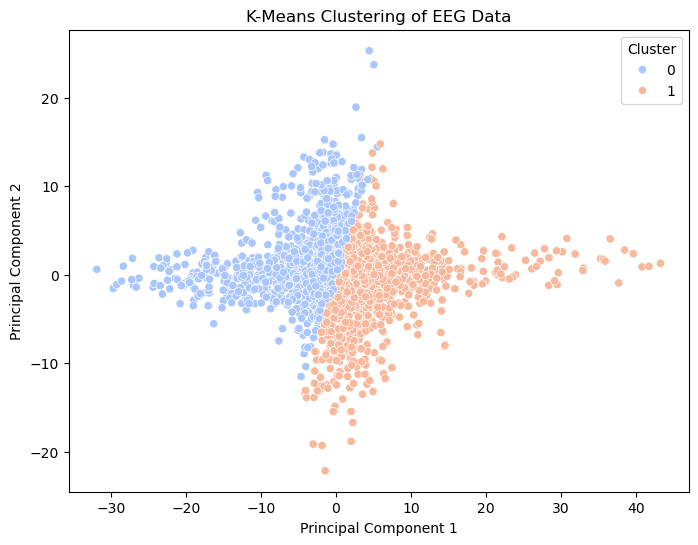

In [10]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['PCA1'], y=df['PCA2'], hue=df['Cluster'], palette='coolwarm')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering of EEG Data')
plt.legend(title='Cluster')
plt.show()

In [11]:
from sklearn.cluster import  DBSCAN
dbscan = DBSCAN(eps=2, min_samples=5)
df['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)
df['Cluster_DBSCAN'] = df['Cluster_DBSCAN'].apply(lambda x: 1 if x != -1 else 0)  # Ensure only 0 and 1 clusters

test_clusters_kmeans = kmeans.predict(X_test)
test_clusters_dbscan = dbscan.fit_predict(X_test)

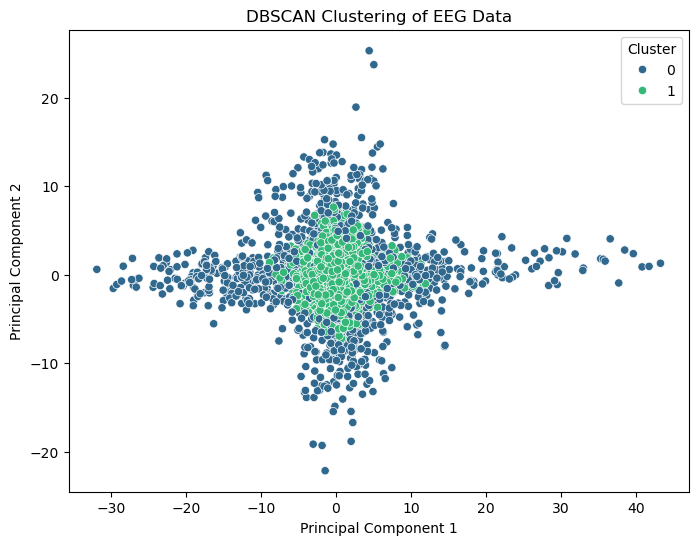

In [12]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['PCA1'], y=df['PCA2'], hue=df['Cluster_DBSCAN'], palette='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('DBSCAN Clustering of EEG Data')
plt.legend(title='Cluster')
plt.show()

In [13]:
print("Test Cluster Assignments:", test_clusters)

Test Cluster Assignments: [0 1 1 ... 1 0 1]


In [14]:
def predict_cluster(sample):
    if len(sample) != len(eeg_features):
        raise ValueError(f"Input sample must have {len(eeg_features)} values, but got {len(sample)}.")
    sample_df = pd.DataFrame([sample], columns=eeg_features) 
    sample_scaled = scaler.transform(sample_df)
    cluster = kmeans.predict(sample_scaled)[0]
    cluster_labels = {0: "Seizure", 1: "Non-Seizure"}  
    return cluster, cluster_labels.get(cluster, "Unknown")

In [15]:
non_seizure_input = [0.057813093, -1.335265708, 4.640479834, 0.21957263, 7.473817197, 2.314841544, 1.918096675, -9.257533341, 9.089943478, -7.104518775, 2.414574162, 7.827253336, -3.781129703, 4.732689026, -5.738116843, -7.654468958, 2.332482692, 3.561578738, 2.406168609, 8.67108511, 1.046758895, -3.716191836, -30.57954227, -2.241480334, 1.415335067, 2.406645742, 12.86405942, 4.02109921, -2.828598465, -2.588735036, 2.637905227, -5.226618413]
predicted_cluster, predicted_label = predict_cluster(non_seizure_input)
print(f"Predicted Cluster for Non-Seizure Input: {predicted_cluster} ({predicted_label})")

Predicted Cluster for Non-Seizure Input: 1 (Non-Seizure)


In [16]:
seizure_input = [-2.5, 3.1, -4.0, 2.8, -6.1, 1.9, -3.7, 5.2, -4.8, 3.3, -2.9, 4.1, -3.2, 6.0, -2.5, 4.7, -3.8, 2.6, -5.5, 3.9, -4.3, 2.0, -3.9, 4.5, -6.2, 3.7, -2.8, 5.0, -4.1, 2.3, -3.6, 4.2]
predicted_cluster, predicted_label = predict_cluster(seizure_input)
print(f"Predicted Cluster for Seizure Input: {predicted_cluster} ({predicted_label})")

Predicted Cluster for Seizure Input: 0 (Seizure)


In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df.iloc[:, :-1]  
y = df.iloc[:, -1]   


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


y_pred = rf_model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Model Accuracy: {accuracy:.2f}")


Random Forest Model Accuracy: 0.94


In [17]:
import pickle

In [18]:
with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

with open("dbscan_model.pkl", "wb") as f:
    pickle.dump(dbscan, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)